In [12]:
import pandas as pd
df = pd.read_csv("/content/healthcare_data_cleaning_dataset.csv")
df

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20
...,...,...,...,...,...,...,...,...,...
5095,11764,NaN,Female,Mumbai,COVID-19,15,NaN,0,2023-09-22
5096,17597,NaN,Female,Chennai,Asthma,2,NaN,0,2023-06-26
5097,19171,NaN,Female,Mumbai,Flu,1,NaN,1,2023-12-31
5098,13854,NaN,Female,Bangalore,Flu,17,NaN,0,2023-01-18


In [13]:
# Ques1 find missing value in each column
df.isnull().sum()

,0
Patient_ID,0
Age,600
Gender,0
City,0
Diagnosis,0
Hospital_Visits,0
Treatment_Cost,593
Insurance_Coverage,0
Admission_Date,0


In [14]:
#Ques 1. percentage of missing values
(df.isnull().sum() / len(df)*100).round(2)

,0
Patient_ID,0.00
Age,11.76
Gender,0.00
City,0.00
Diagnosis,0.00
Hospital_Visits,0.00
Treatment_Cost,11.63
Insurance_Coverage,0.00
Admission_Date,0.00


In [15]:
#Ques 2.  here we see what is detailed view of age column
df["Age"].describe()

,Age
count,4500.000000
mean,49.597556
std,28.663852
min,0.000000
25%,25.000000
50%,50.000000
75%,74.000000
max,99.000000


<Axes: >

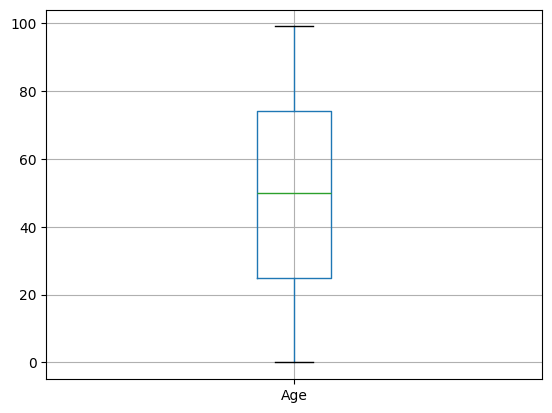

In [16]:
# ques 2 In this we indentify whether Mean is suitable or median is suitable to fill missing value.
import matplotlib.pyplot  as plt
df.boxplot("Age")

In [17]:
# ques2 here we replace null value with mean because their is no outliers..
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [18]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
City,0
Diagnosis,0
Hospital_Visits,0
Treatment_Cost,593
Insurance_Coverage,0
Admission_Date,0


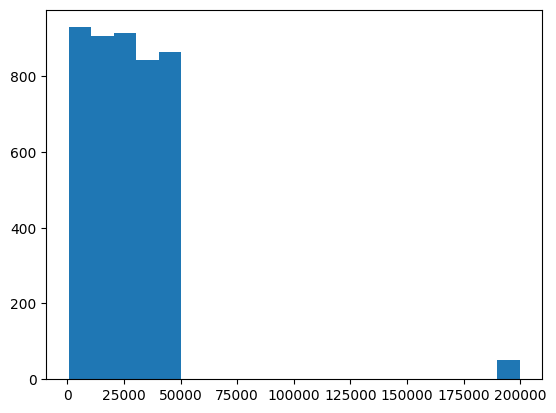

In [19]:
''' Ques 3The histogram shows that Treatment_Cost is highly
 right-skewed with a few very high-cost treatments (outliers).
 Therefore, I used median imputation because the median is not affected by
 extreme values and better represents the typical treatment cost.'''
plt.hist(df["Treatment_Cost"], bins = 20)
plt.show()

In [20]:
df["Treatment_Cost"].skew()

np.float64(4.485699649227538)

In [21]:
df["Treatment_Cost"].describe()

,Treatment_Cost
count,4507.000000
mean,26920.151157
std,23224.930985
min,526.000000
25%,12498.000000
50%,24797.000000
75%,37922.000000
max,199702.965333


In [22]:
# Ques 3 missing treatment cost replace ho gyi
df["Treatment_Cost"] = df["Treatment_Cost"].fillna(df["Treatment_Cost"].median())

In [23]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
City,0
Diagnosis,0
Hospital_Visits,0
Treatment_Cost,0
Insurance_Coverage,0
Admission_Date,0


In [24]:
# Ques 4 indentify duplicates records
df.duplicated().sum()

np.int64(99)

In [25]:
df[df.duplicated()]

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
5000,15126,49.597556,Male,Hyderabad,Asthma,1,24797.0,1,2023-01-19
5001,15108,49.597556,Male,Hyderabad,Asthma,3,24797.0,0,2023-01-27
5002,10441,49.597556,Male,Chennai,Flu,3,24797.0,0,2023-07-08
5003,15975,49.597556,Female,Hyderabad,Flu,10,24797.0,0,2023-06-01
5004,18427,49.597556,Female,Delhi,COVID-19,13,24797.0,1,2023-03-04
...,...,...,...,...,...,...,...,...,...
5094,11571,49.597556,Female,Chennai,COVID-19,4,24797.0,0,2023-01-28
5096,17597,49.597556,Female,Chennai,Asthma,2,24797.0,0,2023-06-26
5097,19171,49.597556,Female,Mumbai,Flu,1,24797.0,1,2023-12-31
5098,13854,49.597556,Female,Bangalore,Flu,17,24797.0,0,2023-01-18


In [26]:
# Ques 4 remove duplicates
df.drop_duplicates(inplace = True)

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.shape

(5001, 9)

In [29]:
df[(df["Age"] < 0) | (df["Age"] > 100)]

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date


In [30]:
# Ques 5. invalid records
df[df["Age"]<= 0].count()

,0
Patient_ID,49
Age,49
Gender,49
City,49
Diagnosis,49
Hospital_Visits,49
Treatment_Cost,49
Insurance_Coverage,49
Admission_Date,49


There are only 49 rows whose age is 0 and it is around 1 percent of total records. So whenever it is 1% or less than 1% we use to remove it. If in case the rows will be 20%-30% then we should correct it deffinetly impact the result..

In [31]:
df = df[df["Age"]> 0]

In [32]:
df[df["Age"]<= 0].count()

,0
Patient_ID,0
Age,0
Gender,0
City,0
Diagnosis,0
Hospital_Visits,0
Treatment_Cost,0
Insurance_Coverage,0
Admission_Date,0


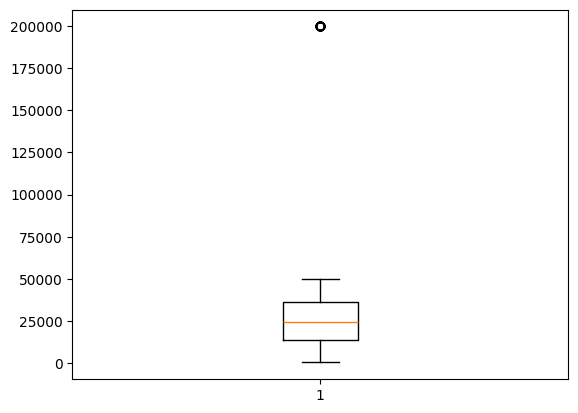

In [36]:
#Ques 6. detect ouliers
import matplotlib.pyplot as plt
plt.boxplot(df["Treatment_Cost"])
plt.show()

In [40]:
Q1 = df["Treatment_Cost"].quantile(0.25)
Q3 = df["Treatment_Cost"].quantile(0.75)

IQR = Q3 - Q1

LL = Q1 - (1.5 * IQR)
UL = Q3 + (1.5 * IQR)
outliers = df[(df["Treatment_Cost"] < LL) | (df["Treatment_Cost"] > UL)]


In [41]:
outliers.shape[0]

49

In [43]:
len(outliers)

49

In [49]:
#Q7. Outlier Treatment
lower = df["Treatment_Cost"].quantile(.05)
upper = df["Treatment_Cost"].quantile(.95)

df["Treatment_Cost"] = df["Treatment_Cost"].clip(lower=lower, upper=upper)

/tmp/ipykernel_2277/3467760866.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Treatment_Cost"] = df["Treatment_Cost"].clip(lower=lower, upper=upper)


In [51]:
df["Treatment_Cost"].describe()

,Treatment_Cost
count,4952.000000
mean,25217.301414
std,13587.853775
min,3210.450000
25%,13760.750000
50%,24797.000000
75%,36542.250000
max,47945.250000


In [54]:
p90 = df["Treatment_Cost"].quantile(0.05)
print(p90)

3215.1525


In [60]:
# Ques 8 new column
import numpy as np

df["Treatment_Cost_Log"] = np.log1p(df["Treatment_Cost"])

/tmp/ipykernel_2277/4042012678.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Treatment_Cost_Log"] = np.log1p(df["Treatment_Cost"])


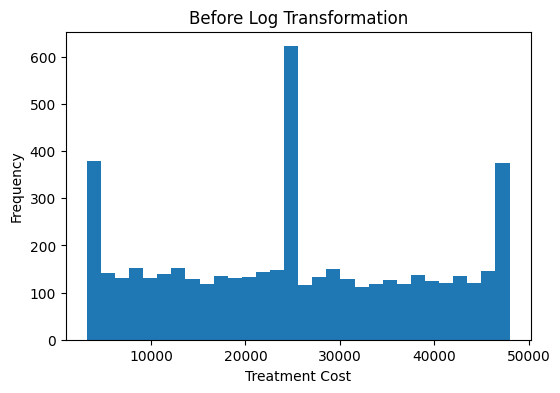

In [61]:
#Ques 8 before transformation
plt.figure(figsize=(6,4))
plt.hist(df["Treatment_Cost"], bins=30)
plt.title("Before Log Transformation")
plt.xlabel("Treatment Cost")
plt.ylabel("Frequency")
plt.show()


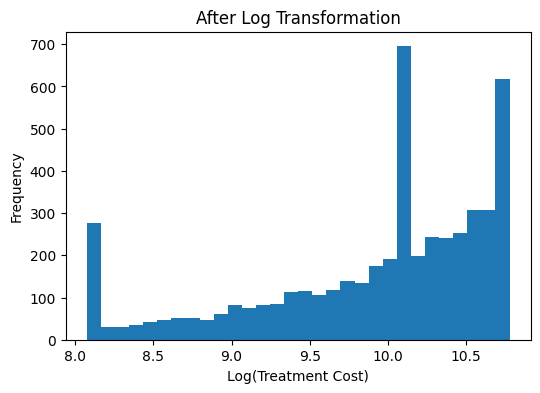

In [62]:
# after transformation...
plt.figure(figsize=(6,4))
plt.hist(df["Treatment_Cost_Log"], bins=30)
plt.title("After Log Transformation")
plt.xlabel("Log(Treatment Cost)")
plt.ylabel("Frequency")
plt.show()

In [63]:
#ques8 comapring both
print("Before Transformation")
print(df["Treatment_Cost"].describe())

print("\nAfter Transformation")
print(df["Treatment_Cost_Log"].describe())

Before Transformation
count     4952.000000
mean     25217.301414
std      13587.853775
min       3210.450000
25%      13760.750000
50%      24797.000000
75%      36542.250000
max      47945.250000
Name: Treatment_Cost, dtype: float64

After Transformation
count    4952.000000
mean        9.917635
std         0.753339
min         8.074478
25%         9.529648
50%        10.118518
75%        10.506252
max        10.777836
Name: Treatment_Cost_Log, dtype: float64


In [64]:
# ques 9 time based missing handling.
df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])

/tmp/ipykernel_2277/2813216351.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])


In [66]:
df = df.sort_values(by = "Admission_Date")

In [68]:
df["Admission_Date"] = df["Admission_Date"].ffill()
df["Admission_Date"] = df["Admission_Date"].bfill()

In [69]:
print(df["Admission_Date"].isnull().sum())

0


**Forward** fill was used because admission records follow a chronological order. Filling missing dates with the previous valid admission date preserves the time sequence and avoids using future information, making it more appropriate for time-based data.

If you used Backward Fill instead:

Backward fill was used because the missing values were at the beginning of the dataset, where no previous valid date was available. Filling with the next valid date maintains a logical sequence.**bold text**